100%|██████████| 9.91M/9.91M [00:08<00:00, 1.15MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 116kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 968kB/s] 
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Epoch 1/5 - Loss: 0.2069
Epoch 2/5 - Loss: 0.0600
Epoch 3/5 - Loss: 0.0417
Epoch 4/5 - Loss: 0.0336
Epoch 5/5 - Loss: 0.0272


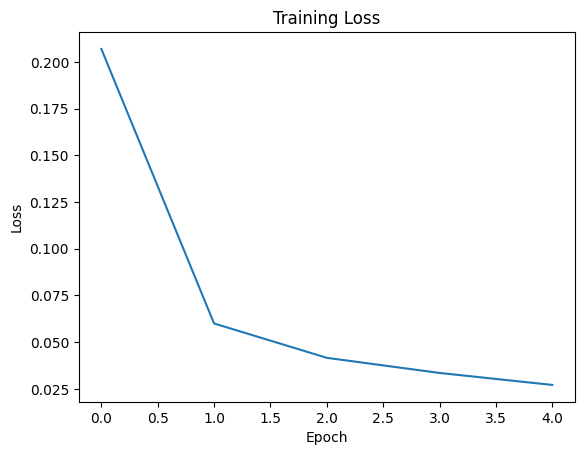

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -------------------------
# 1. Load MNIST Dataset
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# -------------------------
# 2. Build CNN Model
# -------------------------
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.cnn(x)
        return self.fc(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SmallCNN().to(device)

# -------------------------
# 3. Training Setup
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5

losses = []

# -------------------------
# 4. Training Loop
# -------------------------
for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

# -------------------------
# 5. Plot loss curve
# -------------------------
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("training_loss.png")
plt.show()